<a href="https://colab.research.google.com/github/sergiocostaifes/PPCOMP_RNA/blob/main/RNA_trabalho02_mnist_original_cnn_pytorch_S%C3%A9rgio_Costa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho 2 — Classificação do MNIST original com CNN

Aluno: Sérgio Henrique Cerqueira Costa - 20251MPCA0080

Disciplina: Redes Neurais Artificiais

Professor: Francisco Boldt

Este notebook faz a classificação de dígitos manuscritos do MNIST original usando uma rede neural convolucional.

A base MNIST é baixada a partir dos arquivos originais em formato IDX compactado (`.gz`).  
Não é usado `keras.datasets.mnist` nem `torchvision.datasets.MNIST`.

O fluxo geral consiste em:

1. baixar os arquivos originais;
2. ler os arquivos IDX;
3. fazer o pré-processamento;
4. montar uma CNN simples;
5. treinar e avaliar o modelo.


In [1]:
# Bibliotecas utilizadas

import os
import gzip
import struct
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [2]:
# Reprodutibilidade básica

np.random.seed(42)
torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Dispositivo usado:", device)


Dispositivo usado: cuda


## 1. Download do MNIST original

O MNIST original é distribuído em quatro arquivos IDX compactados:

- imagens de treino;
- rótulos de treino;
- imagens de teste;
- rótulos de teste.

Aqui o download é feito diretamente dos arquivos `.gz` em formato IDX — os mesmos arquivos originais distribuídos por Yann LeCun, apenas hospedados em espelhos públicos confiáveis (Google CVDF e AWS) por estabilidade de acesso. Não se usa o carregador pronto do Keras.


In [3]:
# Pasta local para armazenar os arquivos baixados

DATA_DIR = Path("mnist_original")
DATA_DIR.mkdir(exist_ok=True)

# Arquivos originais do MNIST em formato IDX compactado.
# Usamos URLs públicas que hospedam os arquivos originais.
MNIST_FILES = {
    "train_images": "train-images-idx3-ubyte.gz",
    "train_labels": "train-labels-idx1-ubyte.gz",
    "test_images":  "t10k-images-idx3-ubyte.gz",
    "test_labels":  "t10k-labels-idx1-ubyte.gz",
}

URLS_BASE = [
    "https://storage.googleapis.com/cvdf-datasets/mnist/",
    "https://ossci-datasets.s3.amazonaws.com/mnist/",
]

def baixar_arquivo(nome_arquivo):
    destino = DATA_DIR / nome_arquivo

    if destino.exists():
        print(f"Arquivo já existe: {destino}")
        return destino

    ultimo_erro = None

    for base in URLS_BASE:
        url = base + nome_arquivo
        try:
            print(f"Baixando {url}")
            urllib.request.urlretrieve(url, destino)
            print(f"Salvo em: {destino}")
            return destino
        except Exception as erro:
            ultimo_erro = erro
            print(f"Falhou em {url}: {erro}")

    raise RuntimeError(f"Não foi possível baixar {nome_arquivo}") from ultimo_erro

for nome in MNIST_FILES.values():
    baixar_arquivo(nome)


Baixando https://storage.googleapis.com/cvdf-datasets/mnist/train-images-idx3-ubyte.gz
Salvo em: mnist_original/train-images-idx3-ubyte.gz
Baixando https://storage.googleapis.com/cvdf-datasets/mnist/train-labels-idx1-ubyte.gz
Salvo em: mnist_original/train-labels-idx1-ubyte.gz
Baixando https://storage.googleapis.com/cvdf-datasets/mnist/t10k-images-idx3-ubyte.gz
Salvo em: mnist_original/t10k-images-idx3-ubyte.gz
Baixando https://storage.googleapis.com/cvdf-datasets/mnist/t10k-labels-idx1-ubyte.gz
Salvo em: mnist_original/t10k-labels-idx1-ubyte.gz


## 2. Leitura dos arquivos IDX

Os arquivos do MNIST não vêm como imagens `.png`.  
Eles vêm em um formato binário chamado IDX.

Por isso, abaixo há duas funções simples:

- uma para ler imagens;
- outra para ler rótulos.


In [4]:
def ler_imagens_idx(caminho):
    with gzip.open(caminho, "rb") as f:
        magic, quantidade, linhas, colunas = struct.unpack(">IIII", f.read(16))

        if magic != 2051:
            raise ValueError(f"Magic number inválido para imagens: {magic}")

        dados = np.frombuffer(f.read(), dtype=np.uint8)
        imagens = dados.reshape(quantidade, linhas, colunas)

    return imagens


def ler_rotulos_idx(caminho):
    with gzip.open(caminho, "rb") as f:
        magic, quantidade = struct.unpack(">II", f.read(8))

        if magic != 2049:
            raise ValueError(f"Magic number inválido para rótulos: {magic}")

        rotulos = np.frombuffer(f.read(), dtype=np.uint8)

    return rotulos


x_train = ler_imagens_idx(DATA_DIR / MNIST_FILES["train_images"])
y_train = ler_rotulos_idx(DATA_DIR / MNIST_FILES["train_labels"])

x_test = ler_imagens_idx(DATA_DIR / MNIST_FILES["test_images"])
y_test = ler_rotulos_idx(DATA_DIR / MNIST_FILES["test_labels"])

print("Treino:", x_train.shape, y_train.shape)
print("Teste:", x_test.shape, y_test.shape)


Treino: (60000, 28, 28) (60000,)
Teste: (10000, 28, 28) (10000,)


## 3. Visualização de algumas imagens

Antes do treinamento, vamos conferir algumas imagens e seus respectivos rótulos.


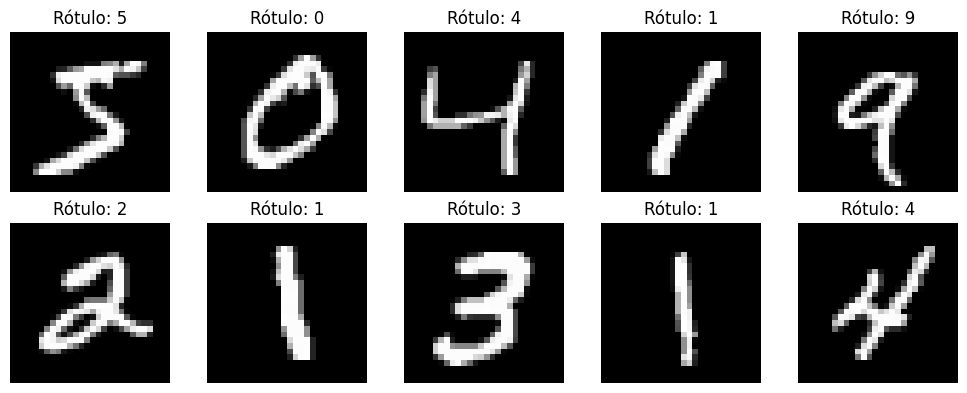

In [5]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Rótulo: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## 4. Pré-processamento

Para a CNN, as imagens precisam ficar no formato:

`quantidade x canais x altura x largura`

Como as imagens são em escala de cinza, há apenas 1 canal.

Também normalizamos os pixels de `0..255` para `0..1`.


In [6]:
# Normalização e ajuste de formato para PyTorch

x_train = x_train.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

x_train = x_train.reshape(-1, 1, 28, 28)
x_test = x_test.reshape(-1, 1, 28, 28)

y_train = y_train.astype(np.int64)
y_test = y_test.astype(np.int64)

print("Formato final treino:", x_train.shape)
print("Formato final teste:", x_test.shape)


Formato final treino: (60000, 1, 28, 28)
Formato final teste: (10000, 1, 28, 28)


In [7]:
# Conversão para tensores

x_train_tensor = torch.tensor(x_train)
y_train_tensor = torch.tensor(y_train)

x_test_tensor = torch.tensor(x_test)
y_test_tensor = torch.tensor(y_test)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print("Lotes de treino:", len(train_loader))
print("Lotes de teste:", len(test_loader))


Lotes de treino: 469
Lotes de teste: 40


## 5. Modelo convolucional

A rede usada é uma CNN simples:

- primeira convolução;
- ReLU;
- MaxPooling;
- segunda convolução;
- ReLU;
- MaxPooling;
- camada densa final para classificar os 10 dígitos.


In [8]:
class CNN_MNIST(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 64)
        self.fc2 = nn.Linear(64, 10)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))  # 28x28 -> 14x14
        x = self.pool(self.relu(self.conv2(x)))  # 14x14 -> 7x7

        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)

        return x


modelo = CNN_MNIST().to(device)
print(modelo)


CNN_MNIST(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=1568, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
  (relu): ReLU()
)


## 6. Treinamento

A função de perda utilizada é a entropia cruzada, que é adequada para classificação multiclasse.

O otimizador utilizado é o Adam.


In [9]:
criterio = nn.CrossEntropyLoss()
otimizador = torch.optim.Adam(modelo.parameters(), lr=0.001)


In [10]:
def treinar(modelo, train_loader, criterio, otimizador, device):
    modelo.train()

    perda_total = 0
    acertos = 0
    total = 0

    for imagens, rotulos in train_loader:
        imagens = imagens.to(device)
        rotulos = rotulos.to(device)

        otimizador.zero_grad()

        saidas = modelo(imagens)
        perda = criterio(saidas, rotulos)

        perda.backward()
        otimizador.step()

        perda_total += perda.item() * imagens.size(0)

        predicoes = saidas.argmax(dim=1)
        acertos += (predicoes == rotulos).sum().item()
        total += rotulos.size(0)

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia


def avaliar(modelo, test_loader, criterio, device):
    modelo.eval()

    perda_total = 0
    acertos = 0
    total = 0

    todos_rotulos = []
    todas_predicoes = []

    with torch.no_grad():
        for imagens, rotulos in test_loader:
            imagens = imagens.to(device)
            rotulos = rotulos.to(device)

            saidas = modelo(imagens)
            perda = criterio(saidas, rotulos)

            perda_total += perda.item() * imagens.size(0)

            predicoes = saidas.argmax(dim=1)
            acertos += (predicoes == rotulos).sum().item()
            total += rotulos.size(0)

            todos_rotulos.extend(rotulos.cpu().numpy())
            todas_predicoes.extend(predicoes.cpu().numpy())

    perda_media = perda_total / total
    acuracia = acertos / total

    return perda_media, acuracia, np.array(todos_rotulos), np.array(todas_predicoes)


In [11]:
EPOCHS = 3

historico = {
    "perda_treino": [],
    "acuracia_treino": [],
    "perda_teste": [],
    "acuracia_teste": []
}

for epoca in range(1, EPOCHS + 1):
    perda_treino, acc_treino = treinar(modelo, train_loader, criterio, otimizador, device)
    perda_teste, acc_teste, _, _ = avaliar(modelo, test_loader, criterio, device)

    historico["perda_treino"].append(perda_treino)
    historico["acuracia_treino"].append(acc_treino)
    historico["perda_teste"].append(perda_teste)
    historico["acuracia_teste"].append(acc_teste)

    print(
        f"Época {epoca}/{EPOCHS} | "
        f"Perda treino: {perda_treino:.4f} | "
        f"Acurácia treino: {acc_treino:.4f} | "
        f"Perda teste: {perda_teste:.4f} | "
        f"Acurácia teste: {acc_teste:.4f}"
    )


Época 1/3 | Perda treino: 0.3478 | Acurácia treino: 0.8987 | Perda teste: 0.1069 | Acurácia teste: 0.9642
Época 2/3 | Perda treino: 0.0868 | Acurácia treino: 0.9741 | Perda teste: 0.0538 | Acurácia teste: 0.9826
Época 3/3 | Perda treino: 0.0592 | Acurácia treino: 0.9819 | Perda teste: 0.0483 | Acurácia teste: 0.9838


## 7. Curva de acurácia

A curva abaixo mostra a evolução da acurácia ao longo das épocas.


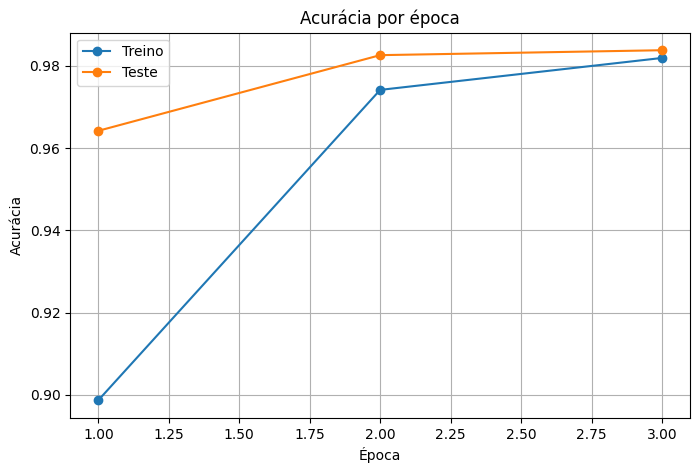

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, EPOCHS + 1), historico["acuracia_treino"], marker="o", label="Treino")
plt.plot(range(1, EPOCHS + 1), historico["acuracia_teste"], marker="o", label="Teste")
plt.xlabel("Época")
plt.ylabel("Acurácia")
plt.title("Acurácia por época")
plt.legend()
plt.grid(True)
plt.show()


## 8. Avaliação final

Após o treinamento, o modelo foi avaliado no conjunto de teste.


In [13]:
perda_final, acc_final, rotulos_reais, predicoes = avaliar(modelo, test_loader, criterio, device)

print(f"Perda final no teste: {perda_final:.4f}")
print(f"Acurácia final no teste: {acc_final:.4f}")


Perda final no teste: 0.0483
Acurácia final no teste: 0.9838


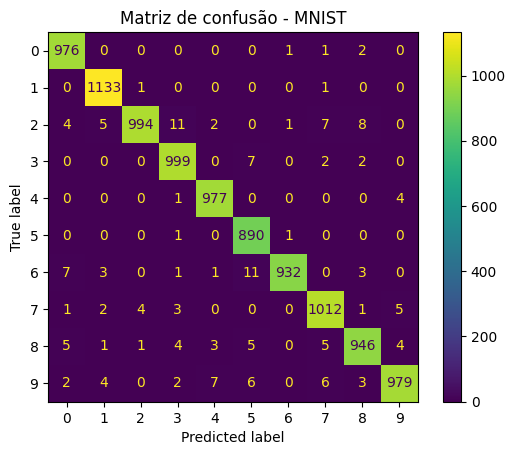

In [14]:
matriz = confusion_matrix(rotulos_reais, predicoes)

disp = ConfusionMatrixDisplay(confusion_matrix=matriz, display_labels=list(range(10)))
disp.plot(values_format="d")
plt.title("Matriz de confusão - MNIST")
plt.show()


## 9. Exemplos de predição

A seguir estão apresentadas algumas imagens do conjunto de teste com o rótulo real e a predição da rede.


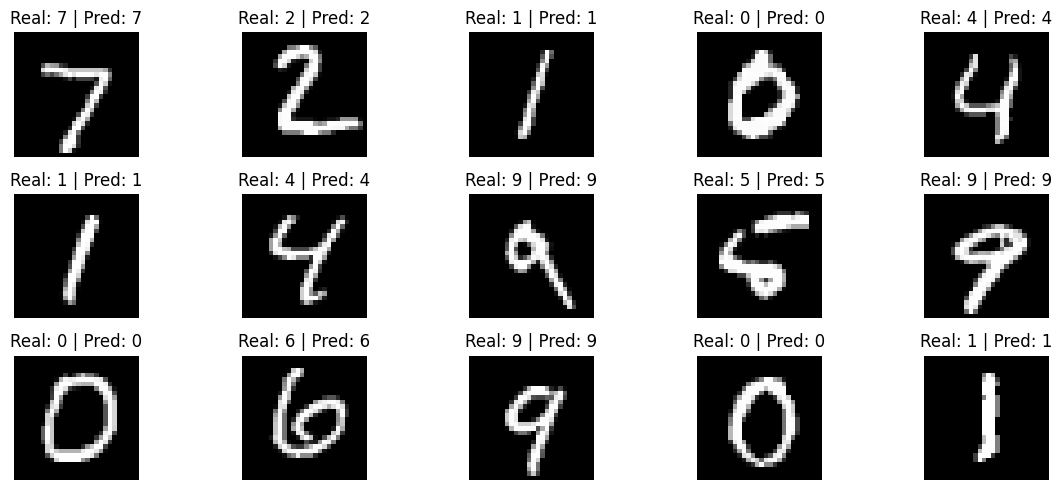

In [15]:
plt.figure(figsize=(12, 5))

for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap="gray")
    plt.title(f"Real: {y_test[i]} | Pred: {predicoes[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()


## Conclusão

O trabalho executou uma rede neural convolucional para classificação do MNIST original.

A base foi baixada em formato IDX compactado, lida manualmente e pré-processada antes do treinamento.  
Assim, o notebook não utilizou a base pronta fornecida por `keras.datasets.mnist`.

A CNN simples foi suficiente para classificar os dígitos manuscritos com acurácia de 98,38% no conjunto de teste, após apenas 3 épocas de treinamento. A proximidade entre as acurácias de treino (98,19%) e teste (98,38%) indica que não houve overfitting.
